In [40]:
import ee 
from RadGEEToolbox import GenericCollection, LandsatCollection, get_palette
# import GEE_UBM
from GEE_UBM import InputCollections, build_model_ready_collection, OriginalUBMRun, ModifiedUBM1Run
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [2]:
service_account = 'localpythonscripts@ut-gee-ugs-bsf-dev.iam.gserviceaccount.com'
credentials = ee.ServiceAccountCredentials(service_account, 'C:\\Users\\mradwin\\ut-gee-ugs-bsf-dev-53dcc5d729e0.json')
ee.Initialize(credentials=credentials)

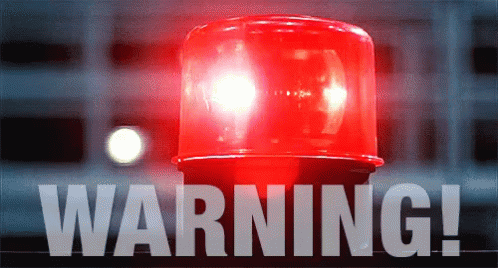

#### Check to see if GRIDMET data counts snow as liquid precip. If it does, we will need to modify the input collection to mask precip values to 0 if the temperature is near 32 degrees F! ⚠️⚠️⚠️

> NOTE: Geo_K is seemingly large for most pixels - likely to be unrealistic and may explain if there is relatively little runoff noted by the model

> NOTE: Wilting point values seem too high, locking the model into scenario 4 for most cases and providing 0 for runoff, recharge, AND AET!

### We should probably use OpenET as an input using the modified UBM to avoid this issue
#### Things to consider:
- Soil thickness might be too large, leading to a bucket that is too large. In this case `available_water` will rarely exceed `field_capacity` and we will observe `runoff = 0` and `recharge = 0` for most pixels. 
    - May want to reconsider `soil thickness` strategy:
        - Maybe we limit soil thickness to root-zone (active hydrological soil depth), where any water leaving the root zone is considered either recharge or runoff. Use the assumption that water leaving the root zone = recharge. In this scenario, if `Geo_K` or `porosity` is over-estimated we will see more `recharge` than `runoff` in most cases. More likely that `Geo_K` would be the variable with more uncertainty. 
        - Maybe we implement a workflow that uses polygonal state geology data and set any areas with bedrock exposure to very low `porosity` and `Geo_K` values, such as mountainous regions for example that have predominantly steep, rocky slopes. Alternatively, or in conjunction, we can implement terrain-based scalars, where terrain that exhibits steeper slopes on average are set to low `porosity` and `geo_k` values, preferring runoff to recharge - and areas with low topography (valleys, basins) retain higher `soil_thickness` and `porosity` values to reflect potentially enhanced storage capabilities for `recharge`.
    - May want to also reconsider `field_capacity`, but this seems lower on the list of values that have large uncertainty as actual soil class data was used to determine this value. Especially because the volumetric component of `field_capacity` scales with the lesser constrained `soil_thickness` 
    - `wilting_point` may be modelled for agricultural plants rather than desert-adapted vegetation prevalent in Utah. We can probably use a vegetation type map alongside prior information of typical diffrences in wilting point for these types of plants to implement scalars against the `wilting_point` raster to lower the `wilting_point` values across the state
- Modified UBM 1 that uses ET as an input may experience cases where `precip < ET` - look for pixels where `precip < ET` and use prior-knowledge to assess the validity
    - If we notice many pixels where `precip < ET` we should think about ways to boost the `available_water` value by incorporating agricultural water diversion. 
- **Spin-up time: treating the first year of analysis as model spin-up!**

In [ ]:
### Defining the UBM input collection for the Original UBM and exporting the collection as an asset to boost model run times later.
run_loop = False
if run_loop:
    years = np.arange(2015, 2025, 1)
    for year in years:
        base_class = InputCollections(start_date=f'{year}-01-01', end_date=f'{year}-12-31', soil_thickness_raster='gNATSGO_filled')
        soil_thickness_raster = base_class.soil_thickness_raster
        # porosity = base_class.get_static_raster('POLARIS_porosity')
        porosity = base_class.get_static_raster('HiHydroSoilPorosity') #HiHydroSoil porosity is lower than POLARIS and more reasonable
        field_capacity = base_class.get_static_raster('OpenLandMapFieldCap') #'UGS_fieldCap - OLM FC looks better to me
        wilting_point = base_class.get_static_raster('HiHydroSoilWiltPoint') #'UGS_wiltingPoint - HiHydroSoil WP looks better to me
        Geo_K = base_class.get_static_raster('UGS_Geo_K')
        precip = base_class.get_precip('GRIDMET_monthly_precip')
        snowmelt = base_class.get_snowmelt('SMAP_monthly_SnowMelt')
        PET = base_class.get_PET('GRIDMET_monthly_PET')
        model_ready_collection = build_model_ready_collection(timeseries_collections_list=[precip, snowmelt, PET], static_images_list=[soil_thickness_raster, porosity, field_capacity, wilting_point, Geo_K])
        dates = model_ready_collection.dates
        export = model_ready_collection.export_to_asset_collection('projects/ut-gee-ugs-bsf-dev/assets/Aggregated_UBM_Input_Collections/UT_2015_2024_PolPor_OLMFC_HSWP_UGSGK_GRDMTPR_SMAPSNW_GRDMTPET_M', 
                                                        region=base_class.Utah_Regional_Boundary.geometry(), scale=11000)

In [ ]:
model_ready_collection_asset = ee.ImageCollection('projects/ut-gee-ugs-bsf-dev/assets/Aggregated_UBM_Input_Collections/UT_2015_2024_PolPor_OLMFC_HSWP_UGSGK_GRDMTPR_SMAPSNW_GRDMTPET_M')
model_ready_collection_asset = GenericCollection(model_ready_collection_asset)
print(model_ready_collection_asset.dates)
print(len(model_ready_collection_asset.dates))
print(model_ready_collection_asset.image_grab(0).bandNames().getInfo())
UBM_col = OriginalUBMRun(model_ready_collection_asset)
dates = UBM_col.dates

In [3]:
### Defining the UBM input collection for the Modified UBM 1 (OpenET as input) and exporting the collection as an asset to boost model run times later.
run_loop = False
if run_loop:
    years = np.arange(2015, 2025, 1)
    for year in years:
        base_class = InputCollections(start_date=f'{year}-01-01', end_date=f'{year}-12-31', soil_thickness_raster='gNATSGO_filled')
        soil_thickness_raster = base_class.soil_thickness_raster
        # porosity = base_class.get_static_raster('POLARIS_porosity')
        porosity = base_class.get_static_raster('HiHydroSoilPorosity') #HiHydroSoil porosity is lower than POLARIS and more reasonable
        field_capacity = base_class.get_static_raster('OpenLandMapFieldCap') #'UGS_fieldCap - OLM FC looks better to me
        wilting_point = base_class.get_static_raster('HiHydroSoilWiltPoint') #'UGS_wiltingPoint - HiHydroSoil WP looks better to me
        Geo_K = base_class.get_static_raster('UGS_Geo_K')
        # precip = base_class.get_precip('GRIDMET_monthly_precip')
        # snowmelt = base_class.get_snowmelt('SMAP_monthly_SnowMelt')
        # PET = base_class.get_PET('GRIDMET_monthly_PET')
        snowmelt_and_precip = base_class.get_precip_and_snowmelt('DAYMET_SNODAS_combined_inputs_monthly')
        # print('Snowmelt and Precip scale: ', snowmelt_and_precip.image_grab(0).select('precip_and_snowmelt_input').projection().nominalScale().getInfo())
        AET = base_class.get_AET('OPEN_ET_EEMETRIC') 
        # print('AET scale: ', AET.image_grab(0).select('AET').projection().nominalScale().getInfo()) # Could also try OpenET_EEMETRIC or OpenET_GEESEBAL
        model_ready_collection = build_model_ready_collection(timeseries_collections_list=[snowmelt_and_precip, AET], static_images_list=[soil_thickness_raster, porosity, field_capacity, wilting_point, Geo_K])
        dates = model_ready_collection.dates
        scale = model_ready_collection.image_grab(0).select('soil_porosity').projection().nominalScale().getInfo()
        # print(scale)
        export = model_ready_collection.export_to_asset_collection('projects/ut-gee-ugs-bsf-dev/assets/Aggregated_Modified1_UBM_Input_Collections/UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M', 
                                                        region=base_class.Utah_Regional_Boundary.geometry(), scale=scale)

In [3]:
model_ready_collection_asset = ee.ImageCollection('projects/ut-gee-ugs-bsf-dev/assets/Aggregated_Modified1_UBM_Input_Collections/UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M')
model_ready_collection_asset = GenericCollection(model_ready_collection_asset)
print(model_ready_collection_asset.dates)
print(len(model_ready_collection_asset.dates))
print(model_ready_collection_asset.image_grab(0).bandNames().getInfo())
UBM_M1_col = ModifiedUBM1Run(model_ready_collection_asset)
dates = UBM_M1_col.dates
print(dates)

['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01', '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01', '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01', '2016-01-01', '2016-02-01', '2016-03-01', '2016-04-01', '2016-05-01', '2016-06-01', '2016-07-01', '2016-08-01', '2016-09-01', '2016-10-01', '2016-11-01', '2016-12-01', '2017-01-01', '2017-02-01', '2017-03-01', '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01', '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01', '2017-12-01', '2018-01-01', '2018-02-01', '2018-03-01', '2018-04-01', '2018-05-01', '2018-06-01', '2018-07-01', '2018-08-01', '2018-09-01', '2018-10-01', '2018-11-01', '2018-12-01', '2019-01-01', '2019-02-01', '2019-03-01', '2019-04-01', '2019-05-01', '2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01', '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01', '2020-10-01', '2020-11-01', '2020

In [8]:
### Checking soil thickness stats for the model input collection
print('mean: ', model_ready_collection_asset.image_grab(-1).select('soil_thickness').reduceRegion(reducer=ee.Reducer.mean(), geometry=base_class.Utah_Regional_Boundary.geometry(), scale=11000).getInfo())
print('max: ', model_ready_collection_asset.image_grab(-1).select('soil_thickness').reduceRegion(reducer=ee.Reducer.max(), geometry=base_class.Utah_Regional_Boundary.geometry(), scale=11000).getInfo())
print('min: ', model_ready_collection_asset.image_grab(-1).select('soil_thickness').reduceRegion(reducer=ee.Reducer.min(), geometry=base_class.Utah_Regional_Boundary.geometry(), scale=11000).getInfo())

mean:  {'soil_thickness': 1134.2792869947657}
max:  {'soil_thickness': 14528.005603518219}
min:  {'soil_thickness': 45.59999942779541}


In [4]:
def convert_depth_to_volume(image):
    """
    Converts pixel values from depth (mm) to volume (cubic meters).
    
    Formula: Area (m^2) * Depth (mm) / 1000 (mm/m) = Volume (m^3)
    """
    # 1. Calculate area of each pixel in square meters
    pixel_area = ee.Image.pixelArea()
    
    # 2. Convert depth to meters (mm / 1000)
    depth_in_meters = image.multiply(0.001)
    
    # 3. Calculate volume
    volume_m3 = pixel_area.multiply(depth_in_meters)
    
    return volume_m3.copyProperties(image, image.propertyNames())

UBM_M1_volume_col = GenericCollection(collection=UBM_M1_col.collection.map(convert_depth_to_volume), start_date='2016-01-01', end_date='2024-12-31')

In [5]:
GSL_basin = ee.FeatureCollection("projects/ut-gee-ugs-bsf-dev/assets/Utah_Watersheds/Merged_GSL_Basin_Watershed").geometry()
GSL_basin_recharge = UBM_M1_volume_col.iterate_zonal_stats(geometries=GSL_basin, band='Recharge', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
print(GSL_basin_recharge)
GSL_basin_runoff = UBM_M1_volume_col.iterate_zonal_stats(geometries=GSL_basin, band='Runoff', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
print(GSL_basin_runoff)
GSL_basin_soil_water = UBM_M1_volume_col.iterate_zonal_stats(geometries=GSL_basin, band='Soil_Water_End_Of_Previous_Timestep', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
print(GSL_basin_soil_water)
GSL_basin_AET = model_ready_collection_asset.iterate_zonal_stats(geometries=GSL_basin, band='AET', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
print(GSL_basin_AET)

           Date  GSL Basin_sum
0    2016-01-01   1.826006e+09
1    2016-02-01   6.438224e+08
2    2016-03-01   1.410970e+09
3    2016-04-01   8.563665e+08
4    2016-05-01   3.671089e+08
..          ...            ...
103  2024-08-01   1.009479e+08
104  2024-09-01   4.914061e+07
105  2024-10-01   7.791113e+07
106  2024-11-01   2.033561e+08
107  2024-12-01   6.514771e+08

[108 rows x 2 columns]
           Date  GSL Basin_sum
0    2016-01-01   6.503045e+08
1    2016-02-01   1.731898e+08
2    2016-03-01   6.152405e+08
3    2016-04-01   2.280043e+08
4    2016-05-01   5.156677e+07
..          ...            ...
103  2024-08-01   2.370561e+06
104  2024-09-01   2.920242e+05
105  2024-10-01   1.146264e+06
106  2024-11-01   7.341233e+06
107  2024-12-01   7.122338e+07

[108 rows x 2 columns]
           Date  GSL Basin_sum
0    2016-01-01   7.402733e+09
1    2016-02-01   7.355315e+09
2    2016-03-01   7.314664e+09
3    2016-04-01   7.194238e+09
4    2016-05-01   6.975461e+09
..          ...       

In [63]:
model_inputs_as_volume = GenericCollection(collection=model_ready_collection_asset.collection.map(convert_depth_to_volume), start_date='2015-01-01', end_date='2024-12-31')
GSL_basin_AET = model_inputs_as_volume.iterate_zonal_stats(geometries=GSL_basin, band='AET', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])
GSL_basin_precip_and_snowmelt = model_inputs_as_volume.iterate_zonal_stats(geometries=GSL_basin, band='precip_and_snowmelt_input', scale=1000, reducer_type='sum', geometry_names=['GSL Basin'])

model_input_stats = pd.concat([GSL_basin_precip_and_snowmelt, GSL_basin_AET['GSL Basin_sum']], axis=1)
model_input_stats = model_input_stats[model_input_stats['Date'] > '2015-12-31']
model_input_stats.columns = ['Date', 'Precip_and_Snowmelt_m3', 'AET_m3']
model_input_stats['Date'] = pd.to_datetime(model_input_stats['Date'])
model_input_stats = model_input_stats.reset_index(drop=True)
print(model_input_stats)

          Date  Precip_and_Snowmelt_m3        AET_m3
0   2016-01-01            3.447997e+09  1.233421e+08
1   2016-02-01            1.058954e+09  2.256506e+08
2   2016-03-01            2.951607e+09  8.644242e+08
3   2016-04-01            2.184977e+09  1.355102e+09
4   2016-05-01            1.687322e+09  1.664288e+09
..         ...                     ...           ...
103 2024-08-01            9.711335e+08  1.898691e+09
104 2024-09-01            4.154527e+08  1.366983e+09
105 2024-10-01            7.449346e+08  8.325211e+08
106 2024-11-01            1.343323e+09  2.926648e+08
107 2024-12-01            2.032435e+09  2.251361e+08

[108 rows x 3 columns]


In [65]:
zonal_stats_df = pd.concat([GSL_basin_recharge, GSL_basin_runoff['GSL Basin_sum'], GSL_basin_soil_water['GSL Basin_sum']], axis=1)
zonal_stats_df.columns = ['Date', 'Recharge_m3', 'Runoff_m3', 'Soil_Water_End_m3']
zonal_stats_df['Date'] = pd.to_datetime(zonal_stats_df['Date'])
zonal_stats_df = pd.concat([zonal_stats_df, model_input_stats[['Precip_and_Snowmelt_m3', 'AET_m3']]], axis=1)
print(zonal_stats_df)

          Date   Recharge_m3     Runoff_m3  Soil_Water_End_m3  \
0   2016-01-01  1.826006e+09  6.503045e+08       7.402733e+09   
1   2016-02-01  6.438224e+08  1.731898e+08       7.355315e+09   
2   2016-03-01  1.410970e+09  6.152405e+08       7.314664e+09   
3   2016-04-01  8.563665e+08  2.280043e+08       7.194238e+09   
4   2016-05-01  3.671089e+08  5.156677e+07       6.975461e+09   
..         ...           ...           ...                ...   
103 2024-08-01  1.009479e+08  2.370561e+06       4.384907e+09   
104 2024-09-01  4.914061e+07  2.920242e+05       4.169433e+09   
105 2024-10-01  7.791113e+07  1.146264e+06       4.269148e+09   
106 2024-11-01  2.033561e+08  7.341233e+06       4.889922e+09   
107 2024-12-01  6.514771e+08  7.122338e+07       5.622474e+09   

     Precip_and_Snowmelt_m3        AET_m3  
0              3.447997e+09  1.233421e+08  
1              1.058954e+09  2.256506e+08  
2              2.951607e+09  8.644242e+08  
3              2.184977e+09  1.355102e+09  

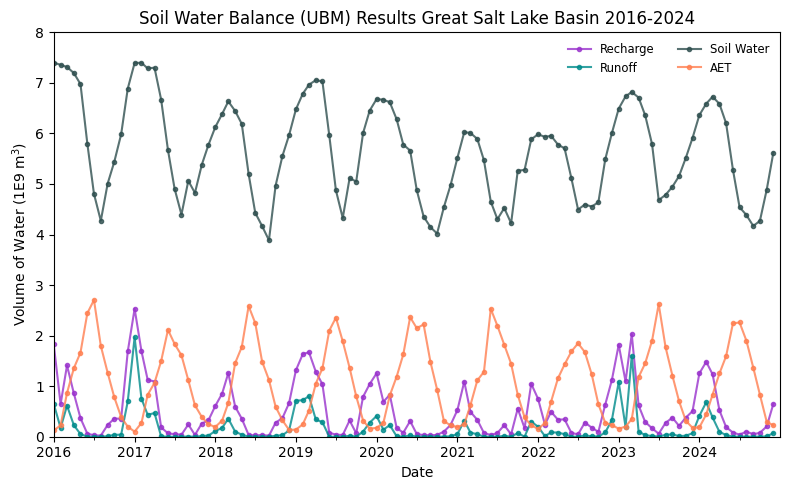

In [67]:
GSL_basin_recharge['Date'] = pd.to_datetime(GSL_basin_recharge['Date'])
GSL_basin_AET['Date'] = pd.to_datetime(GSL_basin_AET['Date'])
markersize = 3
alpha = 0.8
plt.figure(figsize=(8,5))
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Recharge_m3'], marker='o', color='darkorchid', markersize=markersize, alpha=alpha, label='Recharge')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Runoff_m3'], marker='o', color='darkcyan', markersize=markersize, alpha=alpha, label='Runoff')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['Soil_Water_End_m3'], marker='o', color='darkslategrey', markersize=markersize, alpha=alpha, label='Soil Water')
plt.plot(zonal_stats_df['Date'], zonal_stats_df['AET_m3'], marker='o', color='coral', markersize=markersize, alpha=alpha, label='AET')
plt.xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2024-12-31'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(7))
plt.gca().yaxis.get_offset_text().set_visible(False)
plt.ylim(0, 8E9)
plt.title('Soil Water Balance (UBM) Results Great Salt Lake Basin 2016-2024')
plt.xlabel('Date')
plt.ylabel('Volume of Water (1E9 m$^3$)')
plt.legend(loc='upper right', fontsize='small', frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [4]:
export_to_asset = False
if export_to_asset:
    # export = UBM.export_to_asset_collection('projects/ut-gee-ugs-bsf-dev/assets/Original_UBM_Runs/UBM_2015_2024_preferred_test', 
    #                                                 region=base_class.Utah_Regional_Boundary.geometry(), dates=dates, scale=11000)
    export = UBM.export_to_asset_collection('projects/ut-gee-ugs-bsf-dev/assets/Original_UBM_Runs/UBM_2015_2024_preferred_test', 
                                                    region=base_class.Utah_Regional_Boundary.geometry(), scale=11000)

In [9]:
### At first I was exporting the UBM test run as an asset, but when the input collection is an assett it works fine without exporting again. 
### Commenting out but retaining for reference.
################################################


# UBM_asset = ee.ImageCollection('projects/ut-gee-ugs-bsf-dev/assets/Original_UBM_Runs/UBM_2023_2024_preffered_test')
# UBM_col = GenericCollection(UBM_asset, start_date='2023-01-01', end_date='2024-12-31')
# print(UBM_col.dates)
# print(UBM_col.image_grab(-1).bandNames().getInfo())

In [42]:
index = 13
image = UBM_M1_col.image_grab(index)
# image = UBM_col.max
Map = geemap.Map(center=[39.5, -111.5], zoom=7)
Map.addLayer(image, vis_params={'bands':['Runoff'], 'min':0, 'max':300, 'palette':get_palette('inferno')}, name='Runoff') #rdylbu
Map.addLayer(image, vis_params={'bands':['Recharge'], 'min':0, 'max':300, 'palette':get_palette('inferno')}, name='Recharge')
# Map.addLayer(image, vis_params={'bands':['AET'], 'min':0, 'max':300, 'palette':get_palette('rdylbu')}, name='AET')
Map.addLayer(image, vis_params={'bands':['Soil_Water_End_Of_Previous_Timestep'], 'min':0, 'max':500, 'palette':get_palette('rdylbu')}, name='Soil_Water_End_of_Timestep')

# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['precipitation'], 'min':0, 'max':100, 'palette':get_palette('blues')}, name='Precipitation')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['snowmelt'], 'min':0, 'max':50, 'palette':get_palette('blues')}, name='snowmelt')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['soil_thickness'], 'min':0, 'max':2500, 'palette':get_palette('viridis')}, name='soil_thickness')
# # Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['soil_thickness'], 'min':0, 'max':14000, 'palette':get_palette('viridis')}, name='soil_thickness')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['field_capacity'], 'min':0, 'max':500, 'palette':get_palette('viridis')}, name='field_capacity')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['wilting_point'], 'min':0, 'max':500, 'palette':get_palette('viridis')}, name='wilting_point')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['Geo_K'], 'min':0, 'max':10000, 'palette':get_palette('viridis')}, name='Geo_K')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['soil_porosity'], 'min':0, 'max':0.5, 'palette':get_palette('viridis')}, name='soil_porosity')
# Map.addLayer(model_ready_collection_asset.image_grab(index), vis_params={'bands':['PET'], 'min':0, 'max':500, 'palette':get_palette('oranges')}, name='PET')
print(dates[index])
Map

2016-02-01


Map(center=[39.5, -111.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [ ]:
def delete_collection_contents(asset_id, dry_run=True):
    """
    Deletes all images inside an ImageCollection.
    
    Args:
        asset_id (str): The full path to the collection.
        dry_run (bool): If True, only PRINTS what would be deleted. 
                        If False, ACTUALLY deletes files.
    """
    print(f"Scanning {asset_id}...")
    
    try:
        # List all children
        children = ee.data.listAssets({'parent': asset_id})
        files = children.get('assets', [])
        
        if not files:
            print("Collection is already empty.")
            return

        print(f"Found {len(files)} images.")

        if dry_run:
            print("\n--- DRY RUN MODE (Nothing deleted) ---")
            print(f"I WOULD delete the following {len(files)} images:")
            for child in files[:5]: # Print first 5 as a sample
                print(f" [WOULD DELETE]: {child['id']}")
            if len(files) > 5:
                print(f" ... and {len(files)-5} more.")
            print("\nTo actually delete, call this function again with dry_run=False")
            
        else:
            print("\n--- DELETING FILES ---")
            for child in files:
                path = child['id']
                ee.data.deleteAsset(path)
                # print(f"Deleted: {path}") # Uncomment if you want a log of every file
            print(f"✅ Successfully deleted {len(files)} images.")
            
    except Exception as e:
        print(f"❌ Error: {e}")

ASSET_TO_CLEAR = 'projects/ut-gee-ugs-bsf-dev/assets/Aggregated_Modified1_UBM_Input_Collections/UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M' 
# OR
# ASSET_TO_CLEAR = 'projects/ut-gee-ugs-bsf-dev/assets/Utah_SMAP_Daily_Snowmelt_Collection_v1'

# delete_collection_contents(ASSET_TO_CLEAR, dry_run=False)

Scanning projects/ut-gee-ugs-bsf-dev/assets/Aggregated_Modified1_UBM_Input_Collections/UT_HSPor_OLMFC_HSWP_UGSGK_DAYMETSNODAS_OPENET_M...
Found 120 images.

--- DELETING FILES ---
✅ Successfully deleted 120 images.
